In [3]:
! which python

/n/sw/eb/apps/centos7/Anaconda3/2020.11/bin/python


In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [4]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [5]:
from utils.cart import make_wcs, to_cart

In [6]:
from torchinfo import summary

In [7]:
cmap = 'RdBu_r'

In [8]:
! nvidia-smi

Mon Apr 11 08:56:51 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.57.02    Driver Version: 470.57.02    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:06:00.0 Off |                    0 |
| N/A   34C    P0    25W / 250W |      0MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  Tesla V100-PCIE...  On   | 00000000:2F:00.0 Off |                    0 |
| N/A   

In [9]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [10]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
# mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0


## Generative model

In [10]:
data = np.load("../data/samples/data_uniform.npz")
signal_ensemble = data["signal_ensemble"]
flux_fraction = data["flux_fraction"]

In [11]:
from models.module_ros import GlowPLRos
import torch

In [12]:
x = torch.Tensor(signal_ensemble)[:, 2:-2, 2:-2].unsqueeze(1)

In [38]:
model = GlowPLRos(num_channels=256, num_levels=5, num_steps=18, quants=x.max(), add_unif_noise=False)

In [39]:
model.flow.load_state_dict(torch.load("../data/logs/wandb/run-20220409_232245-898p1feo/files/flow.ckpt"))
model.flow.eval();

In [40]:
def calc_z_shapes(n_channel=1, input_size=96, n_flow=18, n_block=5):
    z_shapes = []

    for i in range(n_block - 1):
        input_size //= 2
        n_channel *= 2

        z_shapes.append((n_channel, input_size, input_size))

    input_size //= 2
    z_shapes.append((n_channel * 4, input_size, input_size))

    return z_shapes

In [41]:
model.to('cuda');

In [42]:
from tqdm.notebook import tqdm

In [62]:
n_samples = 50

x_samples = []

for _ in tqdm(range(10)):
    z_sample = []
    z_shapes = calc_z_shapes()
    for z in z_shapes:
        z_new = torch.randn(n_samples, *z)
        z_sample.append(z_new.to('cuda'))

    x_samples_temp = (model.flow.reverse(z_sample, reconstruct=False, quant_int=True))
    x_samples.append(x_samples_temp)

  0%|          | 0/10 [00:00<?, ?it/s]

In [63]:
x_samples = torch.cat(x_samples)

In [64]:
x_samples = x_samples.cpu()

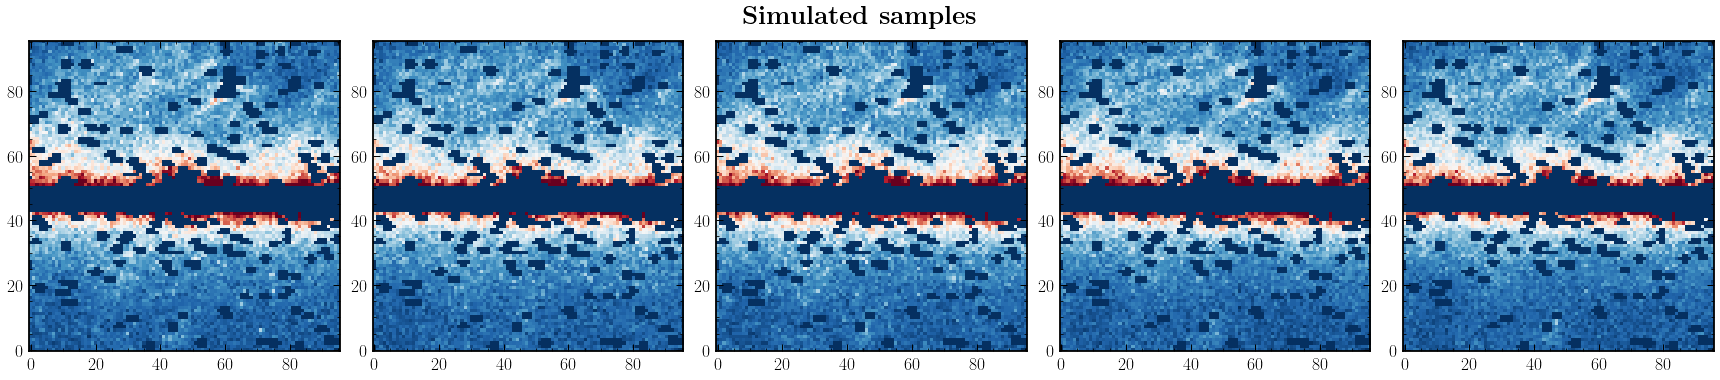

In [65]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2] , cmap=cmap, vmax=100, origin='lower')
    
plt.suptitle(r"\textbf{Simulated samples}", fontsize=26, y=0.9)
plt.tight_layout()

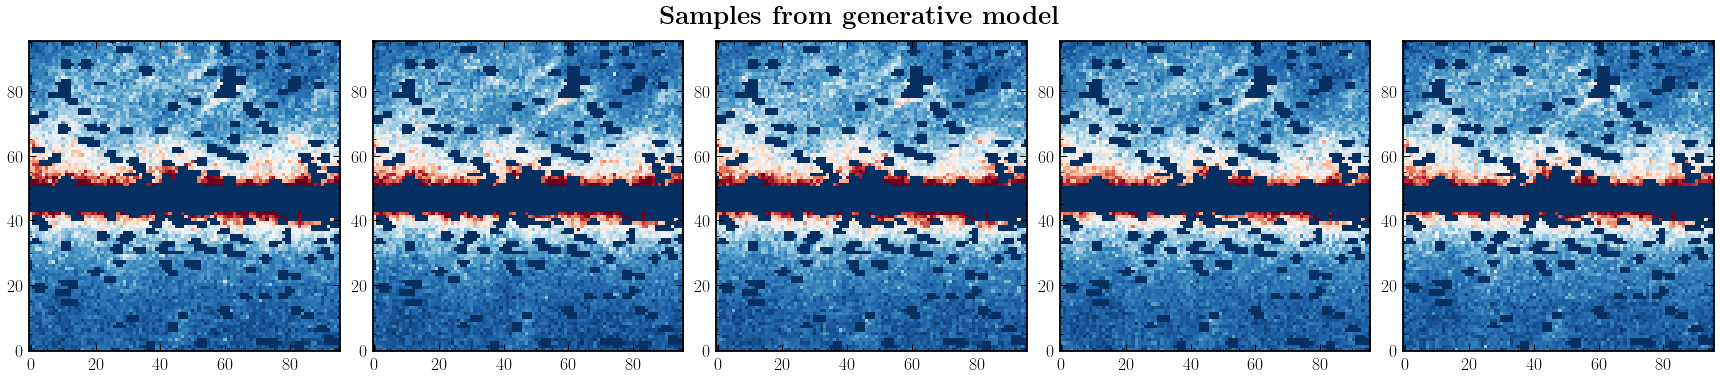

In [66]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmax=100, origin='lower')
    
plt.suptitle(r"\textbf{Samples from generative model}", fontsize=26, y=0.9)
plt.tight_layout()

## Test summaries

In [67]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=128):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

In [68]:
x_pspec_samples = np.array([power_spectrum(x_i) for x_i in x_samples[:, 0, :, :]])
x_pspec_train = np.array([power_spectrum(x_i) for x_i in x[:500, 0]])

x_hist_samples = np.array([counts_histogram(x_i) for x_i in x_samples])
x_hist_train = np.array([counts_histogram(x_i) for x_i in x[:500, 0]])

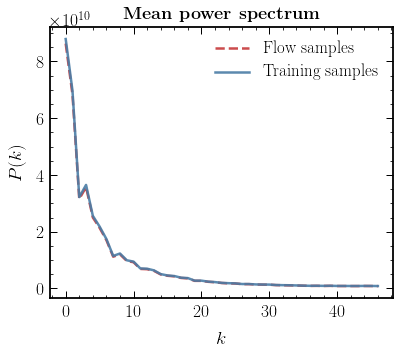

In [69]:
plt.plot(np.nanmean(x_pspec_samples, axis=0)[1:], label="Flow samples", ls='--')
plt.plot(np.mean(x_pspec_train, axis=0)[1:], label="Training samples")

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title(r"\textbf{Mean power spectrum}")
         
plt.legend()

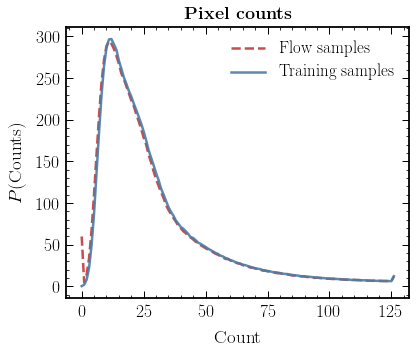

In [70]:
plt.plot(np.nanmean(x_hist_samples, axis=0), label="Flow samples", ls='--')
plt.plot(np.mean(x_hist_train, axis=0), label="Training samples")

plt.xlabel("Count")
plt.ylabel("$P(\mathrm{Counts})$")
plt.title(r"\textbf{Pixel counts}")
         
plt.legend()

In [71]:
from pytorch_wavelets import DWTForward, DWTInverse

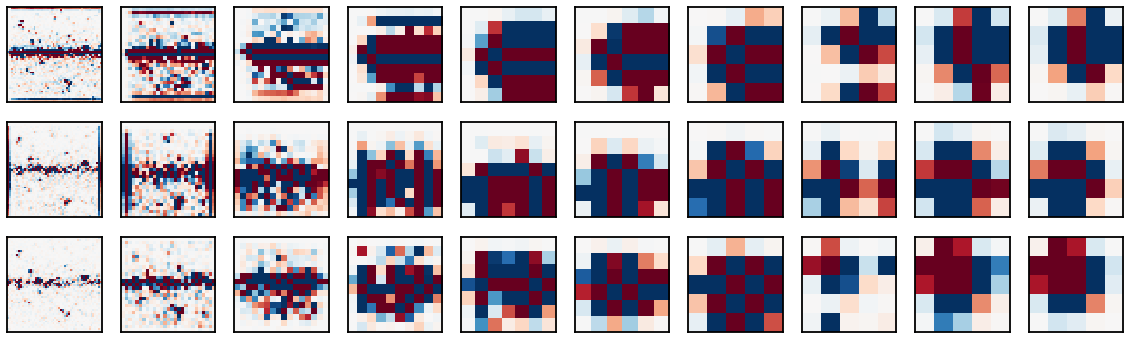

In [72]:
fig, axs = plt.subplots(3, 10, figsize=(20, 6))

xfm = DWTForward(J=10, wave='db3', mode='zero')
Yl, Yh = xfm(x[:500])

for i in range(3):
    for j in range(10):        
        axs[i, j].imshow(Yh[j].mean((0,1))[i], cmap=cmap, vmin=-10, vmax=10)
        axs[i, j].get_xaxis().set_visible(False)
        axs[i, j].get_yaxis().set_visible(False)

In [73]:
x_samples = x_samples.to(torch.float32)

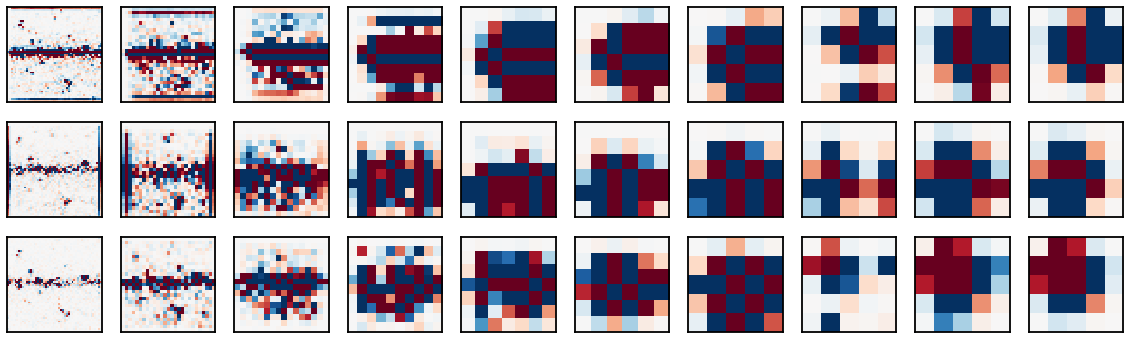

In [74]:
fig, axs = plt.subplots(3, 10, figsize=(20, 6))

xfm = DWTForward(J=10, wave='db3', mode='zero')
Yl, Yh = xfm(x_samples)

for i in range(3):
    for j in range(10):        
        axs[i, j].imshow(Yh[j].mean((0,1))[i], cmap=cmap, vmin=-10, vmax=10)
        axs[i, j].get_xaxis().set_visible(False)
        axs[i, j].get_yaxis().set_visible(False)

## Interpolating in the latent space

In [170]:
def z_interp(z1, z2, weight=0.5):
    z_interp = torch.lerp(z1, z2, weight)
    return z_interp

In [171]:
z, _ = model.flow(x[5:7])

In [176]:
vrange = 100

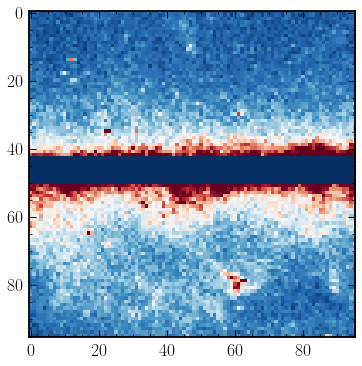

In [177]:
from celluloid import Camera

n_interp = 100

weights_ary = np.linspace(0, 1, n_interp)

fig = plt.figure(figsize=(6,6))

camera = Camera(fig)

for i in range(n_interp):
    
    x_dec = model.flow(z_interp(z[0], z[1], weight=weights_ary[i]).unsqueeze(0), reverse=True)[0]
    
    plt.imshow(x_dec[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange)
    
    camera.snap()

In [178]:
animation = camera.animate()

In [179]:
from IPython.display import HTML
HTML(animation.to_html5_video())

In [45]:
animation.save('latent_interp.gif', fps=15)

## Inference network

In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping

from models.glow import Glow
from models.glow.module import GlowPL

In [76]:
from models.resnet import ResNetEstimator

In [77]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [78]:
# rn = ResNetEstimator(n_out=8)
# torch.softmax(rn(x[:64, 0]), dim=-1)

In [79]:
class ResnetPL(pl.LightningModule):

    def __init__(self, mask=None, lr=3e-4, optimizer_kwargs={'weight_decay': 1e-5}, scheduler='plateau', scheduler_kwargs={'patience':4}):
        """
        Inputs:
            flows - A list of flows (each a nn.Module) that should be applied on the images.
        """
        super().__init__()
        self.resnet = ResNetEstimator(n_out=int(2 * 8))
        self.loss = nn.GaussianNLLLoss(reduction='mean')
        self.lr = lr
        self.optimizer_kwargs = optimizer_kwargs
        
        self.mask = torch.from_numpy(mask).to('cuda')
        
        self.optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, **optimizer_kwargs)

        if scheduler == "cosine":
            self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, **scheduler_kwargs)
        elif scheduler == "plateau":
            self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, **scheduler_kwargs)
        else:
            raise NotImplementedError

    def configure_optimizers(self):
        
        return {"optimizer": self.optimizer, 
                    "lr_scheduler": {
                    "scheduler": self.scheduler,
                    "interval": "epoch",
                    "monitor": "val_loss",
                    "frequency": 1}
                }
    def training_step(self, batch, batch_idx):
        x, y = batch
        x += 1e-6
        x = torch.log10(x)
        out = self.resnet(x[:, 0] * ~self.mask)
        mu, logvar = torch.chunk(out, 2, -1)
        mu = torch.softmax(mu, dim=-1)
        loss = self.loss(mu, y, logvar.exp())
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x += 1e-6
        x = torch.log10(x)
        out = self.resnet(x[:, 0] * ~self.mask)
        mu, logvar = torch.chunk(out, 2, -1)
        mu = torch.softmax(mu, dim=-1)
        loss = self.loss(mu, y, logvar.exp())
        self.log('val_loss', loss)

In [80]:
x = torch.Tensor(signal_ensemble).unsqueeze(1)
x = x[:, :, 2:-2, 2:-2] 
y = torch.Tensor(flux_fraction)

In [81]:
x_mean = 0  # x.mean()
x_std = 1  # x.std()

x_train = (x - x_mean) / x_std
y_train = y

In [82]:
val_fraction = 0.10
n_samples_val = int(val_fraction * len(x_train))

dataset = TensorDataset(x_train, y_train)

dataset_train, dataset_val = random_split(dataset, [len(x_train) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=128, num_workers=0, pin_memory=False, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=128, num_workers=0, pin_memory=False, shuffle=False)

In [84]:
model_inference = ResnetPL(mask=mask_roi[2:-2, 2:-2])

In [85]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=25, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, lr_monitor])
trainer.fit(model=model_inference, train_dataloaders=train_loader, val_dataloaders=val_loader)

model_inference.load_from_checkpoint(checkpoint_callback.best_model_path, mask=mask_roi[2:-2, 2:-2]);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]
Set SLURM handle signals.

  | Name   | Type            | Params
-------------------------------------------
0 | resnet | ResNetEstimator | 12.3 M
1 | loss   | GaussianNLLLoss | 0     
-------------------------------------------
12.3 M    Trainable params
0         Non-trainable params
12.3 M    Total params
49.015    Total estimated model params size (MB)
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:631: UserWarning: Checkpoint directory /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/lightning_logs/version_4198216/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")


Validation sanity check: 0it [00:00, ?it/s]

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:132: UserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:132: UserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [86]:
model_inference.eval();

In [87]:
data = np.load("../data/samples/data_uniform_test.npz")
signal_ensemble = data["signal_ensemble"]
flux_fraction = data["flux_fraction"]

x_test = torch.Tensor(signal_ensemble).unsqueeze(1)
y_test = torch.Tensor(flux_fraction)

x_test = x_test[:, :, 2:-2, 2:-2] 

In [88]:
y_true = flux_fraction[:256]
out = model_inference.resnet(((x_test[:256, 0] + 1e-6).log10() - x_mean) / x_std * ~mask_roi[2:-2, 2:-2])
mu, logvar = torch.chunk(out, 2, -1)
mu = torch.softmax(mu, dim=-1)

In [89]:
mu

tensor([[0.0308, 0.0049, 0.0246,  ..., 0.0189, 0.7490, 0.1536],
        [0.0400, 0.0183, 0.0493,  ..., 0.0200, 0.6876, 0.1617],
        [0.0056, 0.0034, 0.0480,  ..., 0.0185, 0.7475, 0.1614],
        ...,
        [0.0186, 0.0168, 0.0327,  ..., 0.0192, 0.7358, 0.1590],
        [0.0417, 0.0126, 0.0133,  ..., 0.0215, 0.7065, 0.1780],
        [0.0277, 0.0157, 0.0399,  ..., 0.0186, 0.7164, 0.1487]],
       grad_fn=<SoftmaxBackward0>)

  0%|          | 0/8 [00:00<?, ?it/s]

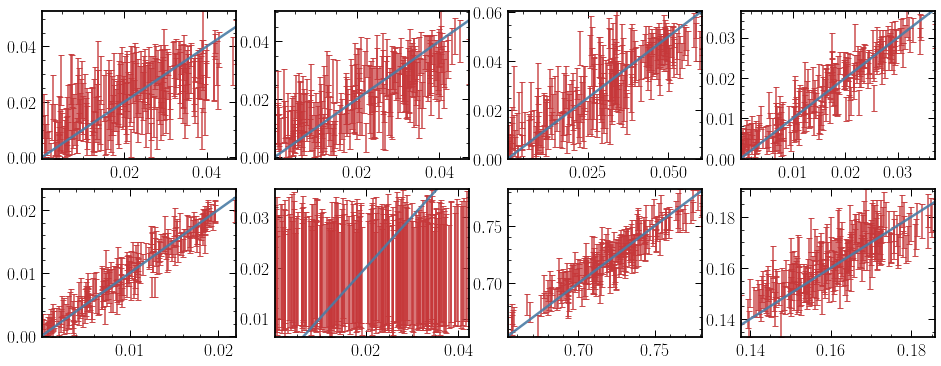

In [90]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 6))
gs = GridSpec(2, 4)

for i in tqdm(range(8)):
    
    ax = fig.add_subplot(gs[i])
    ax.errorbar(y_true[:, i], mu[:, i].detach().numpy(), yerr=logvar[:, i].exp().sqrt().detach().numpy(), fmt='none', capsize=3, capthick=1, elinewidth=1.5)
    ax.plot([0., 1],[0., 1])
    
    ax.set_xlim(np.min(y_true[:, i]), np.max(y_true[:, i]))
    ax.set_ylim(np.min(mu[:, i].detach().numpy() - logvar[:, i].exp().sqrt().detach().numpy()), np.max(mu[:, i].detach().numpy() + logvar[:, i].exp().sqrt().detach().numpy()))

## Counterfactuals

In [91]:
from torch.autograd.functional import vjp, jvp, jacobian

In [92]:
model.to('cuda');

In [93]:
x0 = x_test[3].unsqueeze(0)
log_p_sum, logdet, z0 = model.flow(x0.to('cuda'))

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/nn/functional.py:1806: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


In [94]:
out = model_inference.resnet(((x0[0] + 1e-6).log10() - x_mean) / x_std * torch.Tensor(~mask_roi[2:-2, 2:-2]))
mu, logvar = torch.chunk(out, 2, -1)
mu = torch.softmax(mu, dim=-1)

In [95]:
mu

tensor([[0.0218, 0.0287, 0.0279, 0.0164, 0.0090, 0.0204, 0.7084, 0.1675]],
       grad_fn=<SoftmaxBackward0>)

In [96]:
logvar.exp().sqrt()

tensor([[0.0103, 0.0079, 0.0101, 0.0034, 0.0017, 0.0117, 0.0096, 0.0065]],
       grad_fn=<SqrtBackward0>)

In [97]:
# z_detached = z0.detach()
# z_detached.requires_grad = True
# z_detached.retain_grad()

# def objective(z):
#     return torch.softmax(model_inference.resnet(((model.flow.reverse(z, reconstruct=True, quant_int=False)[0] + 1e-6 - x_mean).log10() / x_std) * torch.Tensor(~mask_roi[2:-2, 2:-2]))[:, :8], dim=-1)[0, 0]

# jacobian(objective, z0)

In [98]:
model_inference.to('cpu')
model.to('cpu');

In [99]:
class DiffeomorphicConfounder(torch.nn.Module):
    def __init__(self, z0):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.z = torch.nn.ParameterList(z0)

    def forward(self, param_idx=0):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        return torch.softmax(model_inference.resnet(((model.flow.reverse(self.z, reconstruct=True, quant_int=False) + 1e-6 - x_mean).log10() / x_std)[0] * torch.Tensor(~mask_roi[2:-2, 2:-2]))[:, :8], dim=-1)[0, param_idx]

In [100]:
z0 = [nn.Parameter(zz.cpu()) for zz in z0];

In [101]:
dc = DiffeomorphicConfounder(z0)

In [102]:
optimizer = torch.optim.SGD(dc.parameters(), lr=0.2)

condition = True

i = 0
i_param = 0

while condition:

    y_pred = dc(i_param)
    
    print(y_pred)
        
    optimizer.zero_grad()
    y_pred.backward()
    optimizer.step()
    
    condition = y_pred > (mu - logvar.exp().sqrt())[0, i_param]
    i += 1

tensor(0.0219, grad_fn=<SelectBackward0>)
tensor(0.0219, grad_fn=<SelectBackward0>)
tensor(0.0218, grad_fn=<SelectBackward0>)
tensor(0.0218, grad_fn=<SelectBackward0>)
tensor(0.0218, grad_fn=<SelectBackward0>)
tensor(0.0218, grad_fn=<SelectBackward0>)
tensor(0.0218, grad_fn=<SelectBackward0>)
tensor(0.0218, grad_fn=<SelectBackward0>)
tensor(0.0218, grad_fn=<SelectBackward0>)
tensor(0.0217, grad_fn=<SelectBackward0>)
tensor(0.0217, grad_fn=<SelectBackward0>)
tensor(0.0217, grad_fn=<SelectBackward0>)
tensor(0.0217, grad_fn=<SelectBackward0>)
tensor(0.0217, grad_fn=<SelectBackward0>)
tensor(0.0217, grad_fn=<SelectBackward0>)
tensor(0.0216, grad_fn=<SelectBackward0>)
tensor(0.0216, grad_fn=<SelectBackward0>)
tensor(0.0216, grad_fn=<SelectBackward0>)
tensor(0.0216, grad_fn=<SelectBackward0>)
tensor(0.0216, grad_fn=<SelectBackward0>)
tensor(0.0216, grad_fn=<SelectBackward0>)
tensor(0.0216, grad_fn=<SelectBackward0>)
tensor(0.0215, grad_fn=<SelectBackward0>)
tensor(0.0215, grad_fn=<SelectBack

In [108]:
x_cf = np.round(model.flow.reverse(dc.z, reconstruct=True, quant_int=False)[0,0].detach().numpy())

In [109]:
torch.softmax(model_inference.resnet(((x0[0] + 1e-6 - x_mean).log10() / x_std * ~mask_roi[2:-2, 2:-2]))[:, :8], dim=-1)

tensor([[0.0218, 0.0287, 0.0279, 0.0164, 0.0090, 0.0204, 0.7084, 0.1675]],
       grad_fn=<SoftmaxBackward0>)

In [110]:
torch.softmax(model_inference.resnet(((torch.Tensor(x_cf).unsqueeze(0) + 1e-6 - x_mean).log10() / x_std * ~mask_roi[2:-2, 2:-2]))[:, :8], dim=-1)

tensor([[0.0125, 0.0298, 0.0239, 0.0215, 0.0099, 0.0209, 0.7124, 0.1692]],
       grad_fn=<SoftmaxBackward0>)

In [111]:
x_cf - x0[0,0].detach().numpy()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

Text(0.5, 1.0, '\\bf{Difference}')

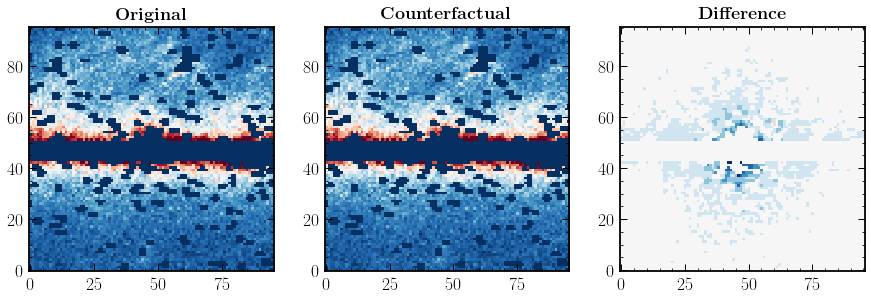

In [112]:
fig, axs = plt.subplots(1, 3, figsize=(10 * 1.5, 3 * 1.5))
vrange = 100

axs[0].imshow(x0[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
axs[0].set_title(r"\bf{Original}")

axs[1].imshow(x_cf * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
axs[1].set_title(r"\bf{Counterfactual}")

axs[2].imshow((x_cf - x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=-5, vmax=5, origin='lower')
axs[2].set_title(r"\bf{Difference}")

/tmp/ipykernel_98933/1597661811.py:3: RuntimeWarning: invalid value encountered in true_divide
  plot = plt.imshow(np.abs(x_cf - x0[0,0].detach().numpy()) / np.sqrt(x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=1, origin='lower')


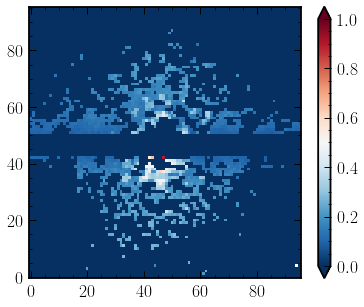

In [113]:
fig, ax = plt.subplots()

plot = plt.imshow(np.abs(x_cf - x0[0,0].detach().numpy()) / np.sqrt(x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=1, origin='lower')

cbar = fig.colorbar(plot, ax=plt.gca(), extend='both')
cbar.minorticks_on()
plt.show()